C:\Users\cempl\AppData\Local\Temp\ipykernel_13064\1693958073.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=D

🚀 Training hardware: cuda
🔄 Found existing brain at 'fusion_model.pth'. Loading weights to resume training...
✅ Dataset Loaded: 300 samples
⏳ Starting Advanced Training for 20 Epochs...


Epoch 1/20: 100%|██████████| 75/75 [00:34<00:00,  2.16it/s, loss=0.0058]


   Epoch 1 Average Loss: 0.006629 | LR: 0.000500


Epoch 2/20: 100%|██████████| 75/75 [00:35<00:00,  2.14it/s, loss=0.0051]


...

   Epoch 18 Average Loss: 0.006089 | LR: 0.000500


Epoch 19/20: 100%|██████████| 75/75 [00:35<00:00,  2.12it/s, loss=0.0064]


   Epoch 19 Average Loss: 0.006074 | LR: 0.000500


Epoch 20/20: 100%|██████████| 75/75 [00:34<00:00,  2.17it/s, loss=0.0055]

   Epoch 20 Average Loss: 0.006024 | LR: 0.000500
✅ Training Complete. Advanced U-Net model saved as 'fusion_model.pth'.


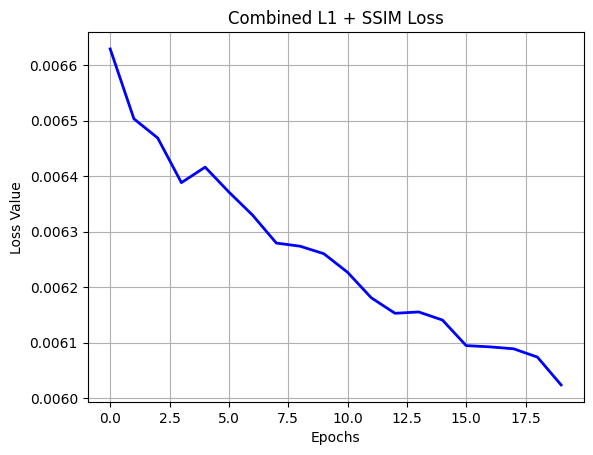

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
import math
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BATCH_SIZE = 4        
LEARNING_RATE = 0.001
EPOCHS = 20          # Increased slightly to let the scheduler work
IMG_SIZE = 256        
MODEL_PATH = "fusion_model.pth" 

# --- HARDWARE SETUP: NATIVE CUDA ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training hardware: {DEVICE}")

# --- 1. THE ADVANCED U-NET MODEL (BatchNorm + Skip Connections) ---
class AdvancedFusionNet(nn.Module):
    def __init__(self):
        super(AdvancedFusionNet, self).__init__()
        
        # Encoder (Downsampling)
        self.enc1 = nn.Sequential(nn.Conv2d(6, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Bottleneck
        self.bottle = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Decoder (Upsampling) + Skip Connections
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        # 64 (from up3) + 64 (from enc2 skip) = 128
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        # 32 (from up2) + 32 (from enc1 skip) = 64
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        
        # Final Output
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.bottle(e3)
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e2], dim=1) # <-- SKIP CONNECTION
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1) # <-- SKIP CONNECTION
        d2 = self.dec2(d2)
        
        return torch.sigmoid(self.final(d2))

model = AdvancedFusionNet().to(DEVICE)

if os.path.exists(MODEL_PATH):
    print(f"🔄 Found existing brain at '{MODEL_PATH}'. Loading weights to resume training...")
    # Because the architecture changed (added BatchNorm/Skips), old weights will fail to load.
    # We catch the error and start fresh if the architectures don't match.
    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        LEARNING_RATE = 0.0005 
    except Exception as e:
        print("⚠️ Old model weights do not match new Advanced U-Net architecture. Starting fresh.")
else:
    print("🆕 No existing model found. Starting training from scratch.")

# --- 2. IMPROVED WARPING (padding_mode='border') ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu':
        grid = grid.to(DEVICE)
        
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    # padding_mode='border' ensures dragged edges stretch instead of turning black
    return F.grid_sample(img_tensor, vgrid, align_corners=True, padding_mode='border')

# --- 3. SSIM + L1 LOSS FUNCTION ---
def get_gaussian_window(window_size, channel):
    def _gaussian(window_size, sigma):
        gauss = torch.Tensor([math.exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
        return gauss/gauss.sum()
    _1d = _gaussian(window_size, 1.5).unsqueeze(1)
    _2d = _1d.mm(_1d.t()).float().unsqueeze(0).unsqueeze(0)
    window = _2d.expand(channel, 1, window_size, window_size).contiguous()
    return window

window = get_gaussian_window(11, 3).to(DEVICE)

def ssim_loss(img1, img2, window):
    mu1 = F.conv2d(img1, window, padding=5, groups=3)
    mu2 = F.conv2d(img2, window, padding=5, groups=3)
    mu1_sq, mu2_sq, mu1_mu2 = mu1.pow(2), mu2.pow(2), mu1 * mu2
    
    sigma1_sq = F.conv2d(img1 * img1, window, padding=5, groups=3) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=5, groups=3) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=5, groups=3) - mu1_mu2
    
    C1, C2 = 0.01**2, 0.03**2
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return 1 - ssim_map.mean()

def combined_loss(pred, target):
    l1 = F.l1_loss(pred, target)
    ssim_val = ssim_loss(pred, target, window)
    return (0.8 * l1) + (0.2 * ssim_val) # 80% L1 (Sharpness) + 20% SSIM (Structure)

# --- 4. OPTIMIZED DATASET LOADER ---
class FrameTripletDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.triplets = []
        flow_dir = os.path.join(root_dir, 'flow')
        for root, _, files in os.walk(flow_dir):
            for file in files:
                if file.endswith('.npy'):
                    self.triplets.append(os.path.join(root, file))
    
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        flow_path = self.triplets[idx]
        rel_path = os.path.relpath(flow_path, os.path.join(self.root_dir, 'flow'))
        base_name = rel_path.replace('_0.npy', '')
        base_img_path = os.path.join(self.root_dir, 'triplets', base_name)
        
        img0 = cv2.imread(base_img_path + '_0.png')
        img1 = cv2.imread(base_img_path + '_1.png')
        img2 = cv2.imread(base_img_path + '_2.png')
        flow = np.load(flow_path)
        
        if img0 is None or img1 is None or img2 is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((2, IMG_SIZE, IMG_SIZE))

        img0 = cv2.resize(img0, (IMG_SIZE, IMG_SIZE))
        img1 = cv2.resize(img1, (IMG_SIZE, IMG_SIZE))
        img2 = cv2.resize(img2, (IMG_SIZE, IMG_SIZE))
        flow = cv2.resize(flow, (IMG_SIZE, IMG_SIZE))
        
        img0 = torch.from_numpy(img0).permute(2, 0, 1).float() / 255.0
        img1 = torch.from_numpy(img1).permute(2, 0, 1).float() / 255.0
        img2 = torch.from_numpy(img2).permute(2, 0, 1).float() / 255.0
        flow = torch.from_numpy(flow).permute(2, 0, 1).float()
        
        return img0, img1, img2, flow

# pin_memory=True radically speeds up the transfer of images from CPU RAM to NVIDIA GPU VRAM
dataset = FrameTripletDataset(root_dir='dataset')
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
print(f"✅ Dataset Loaded: {len(dataset)} samples")

# --- 5. ROBUST TRAINING LOOP ---
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Scheduler: Reduces Learning Rate by half if the loss stops improving for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

loss_history = []
print(f"⏳ Starting Advanced Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    model.train() # Set to training mode (important for BatchNorm)
    epoch_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for img0, target, img2, flow in progress_bar:
        img0, target, img2, flow = img0.to(DEVICE), target.to(DEVICE), img2.to(DEVICE), flow.to(DEVICE)
        
        # 1. Warp
        with torch.no_grad(): # Don't need to track gradients for warping math
            warped_0 = warp_tensor(img0, flow * 0.5)      
            warped_1 = warp_tensor(img2, flow * -0.5)     
        
        # 2. Forward Pass
        cnn_input = torch.cat([warped_0, warped_1], dim=1)
        output = model(cnn_input)
        
        # 3. Calculate Loss (L1 + SSIM)
        loss = combined_loss(output, target)
        
        # 4. Backward Pass & Gradient Clipping
        optimizer.zero_grad()
        loss.backward()
        
        # Clip gradients to prevent "exploding gradients" which ruin the weights
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    # Update the Learning Rate Scheduler
    scheduler.step(avg_loss)
    
    print(f"   Epoch {epoch+1} Average Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# Save the new architecture weights
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Training Complete. Advanced U-Net model saved as '{MODEL_PATH}'.")

# Plot Loss
plt.plot(loss_history, color='blue', linewidth=2)
plt.title("Combined L1 + SSIM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True)
plt.show()